<a href="https://colab.research.google.com/github/thaontp-sonia/114_DS_Project/blob/main/Milestone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
path_data = "/content/drive/MyDrive/Data Science Fundamentals for the Social Sciences/Milestone/keyword_alan_2/Excel"

In [ ]:
os.listdir(path_data)

['0 docs.xlsx',
 '2 entities.xlsx',
 '3 entities - unique.xlsx',
 '4 dyads.xlsx',
 '1 headers.xlsx',
 '5 dyads - unique.xlsx']

In [ ]:
headers = pd.read_excel(os.path.join(path_data, "1 headers.xlsx"))
dyads = pd.read_excel(os.path.join(path_data, "4 dyads.xlsx"))
entities_unique = pd.read_excel(os.path.join(path_data, "3 entities - unique.xlsx"))
docs = pd.read_excel(os.path.join(path_data, "0 docs.xlsx"))
dyads_unique = pd.read_excel(os.path.join(path_data, "5 dyads - unique.xlsx"))

In [ ]:
# Hàm làm sạch tên thực thể (Entity Cleaning)
def clean_name(name):
    if pd.isna(name): return "Unknown"
    name = str(name).lower()
    name = re.sub(r'^[^a-zA-Z0-9]+|[^a-zA-Z0-9]+$', '', name)
    name = " ".join(name.split())
    return name

In [ ]:
# 2. Làm sạch Entity Name
entities_unique['cleaned_name'] = entities_unique['entity_name'].apply(clean_name)
mapping_table = entities_unique.groupby('cleaned_name')['entity_id'].min().reset_index()
mapping_table.columns = ['cleaned_name', 'new_entity_id']
entity_map = pd.merge(entities_unique[['entity_id', 'cleaned_name']], mapping_table, on='cleaned_name')

# 3. Xử lý thời gian và Lọc (2005 - 2009)
headers['header_date'] = pd.to_datetime(headers['header_date'], errors='coerce')
filtered_headers = headers[(headers['header_date'].dt.year >= 2005) &
                           (headers['header_date'].dt.year <= 2009)].copy()

# 4. JOIN bảng (Dyads + Headers)
merged_data = pd.merge(dyads, filtered_headers[['global_header_id', 'header_date']],
                     on='global_header_id', how='inner')

# 5. RE-CODE (Ngắt tại 24/09/2007)
split_date = pd.Timestamp('2007-09-24')
merged_data['period'] = merged_data['header_date'].apply(lambda x: 'Pre-NPA' if x < split_date else 'Post-NPA')
merged_data['year'] = merged_data['header_date'].dt.year

In [ ]:
entity_map

,entity_id,cleaned_name,new_entity_id
0,720869622,usafls,35048898
1,479902065,villafana,479902065
2,707140586,usafls,35048898
3,407708166,ann marie c. (usafls,260388832
4,259776994,sloman,259776994
...,...,...,...
2425,189630680,Unknown,16328263
2426,190062877,Unknown,16328263
2427,105165381,Unknown,16328263
2428,56430102,Unknown,16328263


#Introduce Variables

In [ ]:
variables_table = pd.DataFrame({
    'Variable': ['Period', 'Weight', 'Year', 'Email_Count'],
    'Type': ['Categorical (Re-coded)', 'Continuous (Joined)', 'Covariate', 'Continuous'],
    'Definition': [
        'Time period split around NPA (Pre-NPA vs Post-NPA at 2007-09-24)',
        'Number of emails between a specific dyad (relationship intensity)',
        'The year the communication occurred',
        'Total volume of emails sent/received in a given timeframe'
    ],
    'Source': ['Derived from headers date', 'Joined from 5 dyads unique', '1 headers', 'Calculated from dyads']
})
display(variables_table)

,Variable,Type,Definition,Source
0,Period,Categorical (Re-coded),Time period split around NPA (Pre-NPA vs Post-...,Derived from headers date
1,Weight,Continuous (Joined),Number of emails between a specific dyad (rela...,Joined from 5 dyads unique
2,Year,Covariate,The year the communication occurred,1 headers
3,Email_Count,Continuous,Total volume of emails sent/received in a give...,Calculated from dyads


In [ ]:
# Bước 1: Tính các chỉ số cơ bản và đếm số ngày duy nhất (Unique_Days) trong từng giai đoạn
summary_stats = merged_data.groupby('period').agg(
    Email_Count=('global_header_id', 'count'),
    Unique_Senders=('entity1_id', 'nunique'),
    Unique_Receivers=('entity2_id', 'nunique'),
    Unique_Days=('header_date', 'nunique') # Thêm dòng này để đếm số ngày có liên lạc
)

# Bước 2: Tính số email trung bình mỗi ngày một cách an toàn
summary_stats['Avg_Daily_Emails'] = (summary_stats['Email_Count'] / summary_stats['Unique_Days']).round(2)

# (Tùy chọn) Bỏ cột Unique_Days nếu không muốn hiển thị trong báo cáo
# summary_stats = summary_stats.drop(columns=['Unique_Days'])

display(summary_stats)

,Email_Count,Unique_Senders,Unique_Receivers,Unique_Days,Avg_Daily_Emails
period,,,,,
Post-NPA,20767,379,409,157,132.27
Pre-NPA,1160,71,72,30,38.67


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]

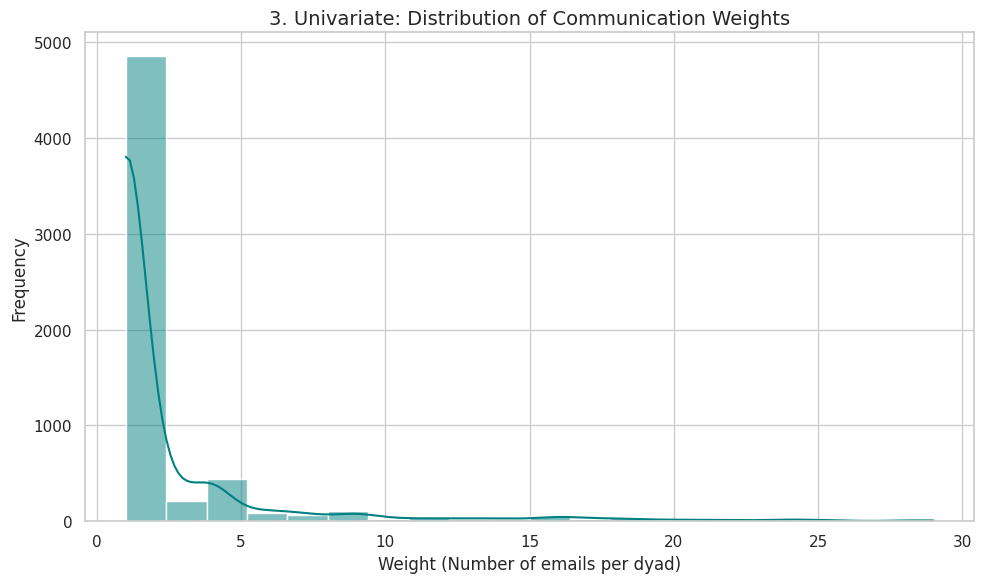

In [ ]:
# Histogram Continuous
plt.figure(figsize=(10, 6))
sns.histplot(dyads_unique[dyads_unique['weight'] < 30]['weight'], bins=20, kde=True, color='teal')

plt.title('3. Univariate: Distribution of Communication Weights', fontsize=14)
plt.xlabel('Weight (Number of emails per dyad)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show() # In ảnh thứ nhất

/tmp/ipykernel_1916/3451178922.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_data, x='year', palette='magma')


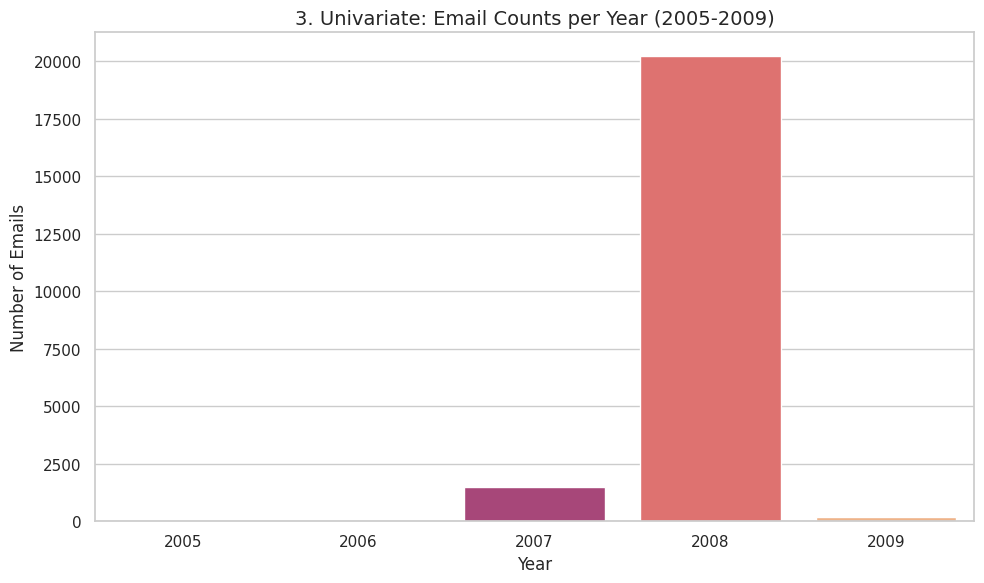

In [ ]:

# 2. Bar graph (Biến phân loại)
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_data, x='year', palette='magma')

plt.title('3. Univariate: Email Counts per Year (2005-2009)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Emails')

plt.tight_layout()
plt.show() # In ảnh thứ hai

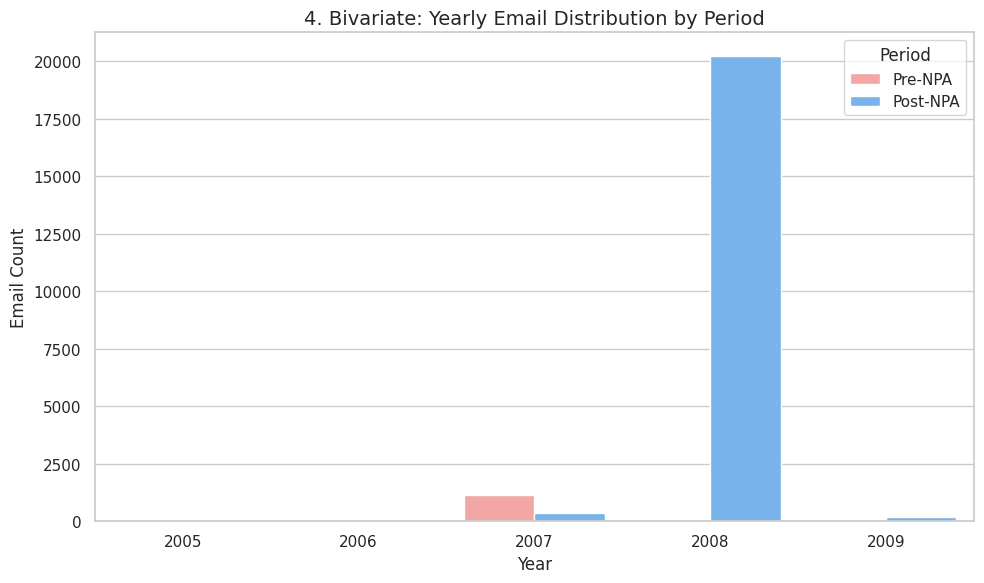

In [ ]:
# 1. Nested Bar Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_data, x='year', hue='period', palette={'Pre-NPA': '#ff9999', 'Post-NPA': '#66b3ff'})

plt.title('4. Bivariate: Yearly Email Distribution by Period', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Email Count')
plt.legend(title='Period')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1916/530189604.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = merged_data.set_index('header_date').resample('M').size().reset_index(name='count')


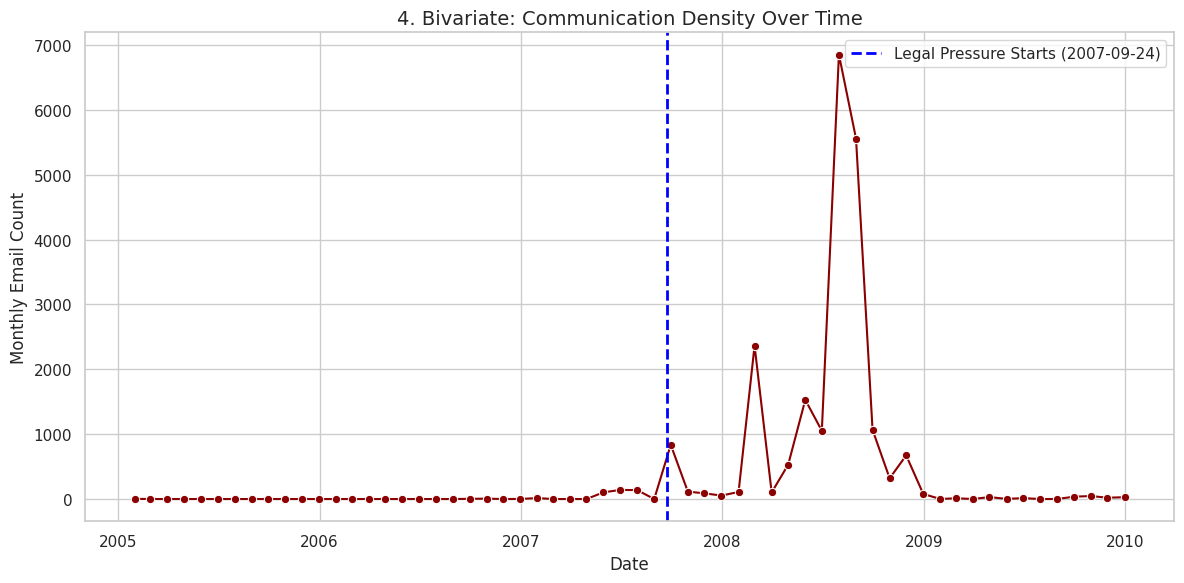

In [ ]:

# 2. Time Series Plot
monthly_data = merged_data.set_index('header_date').resample('M').size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_data, x='header_date', y='count', marker='o', color='darkred')

# Thêm đường mốc thời gian
plt.axvline(split_date, color='blue', linestyle='--', linewidth=2, label='Legal Pressure Starts (2007-09-24)')

plt.title('4. Bivariate: Communication Density Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Monthly Email Count')
plt.legend()

plt.tight_layout()
plt.show()